In [1]:
import glob
import os
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

pd.set_option('display.max_columns', None) # Displays all columns of df

In [2]:
# Loads tracks

tracks_path = r"/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Develop_mobility_analysis/100tp_561-100-50ms-1000g_4_conf561_merged_spots_tracks.csv"
tracks = pd.read_csv(tracks_path)
tracks.head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id
0,0,1,240.354808,700.247277,4911.314072,10202.557700,1.393954,1.229846,1323.055556,0,1.0_0.0,361
1,0,1,223.136631,708.928794,4014.206405,5122.043154,1.647806,1.314527,934.944444,1,1.0_1.0,161
2,1,1,240.641595,700.662313,4968.520453,10962.269196,1.241646,1.156954,1553.083333,0,1.0_0.0,361
3,1,1,225.587597,691.852900,3612.544331,3790.500000,2.326372,2.053595,898.027778,2,1.0_2.0,413
4,1,1,222.966845,709.648257,3948.350167,8244.582731,1.345105,1.342684,1231.333333,1,1.0_1.0,161


In [3]:
# Load all files from one folder

D21_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/Tracking/Run20240226/Cleanfiles_Link5'
D21_path = os.path.join(D21_dir,'*.csv') 
D21_files = glob.glob(D21_path)

D28_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D28/50ms/Tracking/Run20240226/Cleanfiles_Factor4Link5'
D28_path = os.path.join(D28_dir,'*.csv') 
D28_files = glob.glob(D28_path)

D35_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/Tracking/Run20240226/Cleanfiles_Factor4Link5'
D35_path = os.path.join(D35_dir,'*.csv') 
D35_files = glob.glob(D35_path)

D55_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D55/TUBB2B-KI_D55_2%/50ms/Tracking/Run20240226/Cleanfiles_Factor5Link5'
D55_path = os.path.join(D55_dir,'*.csv') 
D55_files = glob.glob(D55_path)

In [4]:
D35_files

['/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/Tracking/Run20240226/Cleanfiles_Factor4Link5/5-2_100tp_561-100-50ms-901g_1_conf561_xyCorrected_spots_tracks_clean.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/Tracking/Run20240226/Cleanfiles_Factor4Link5/27_100tp_561-100-50ms-901g_1_conf561_xyCorrected_spots_tracks_clean.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/Tracking/Run20240226/Cleanfiles_Factor4Link5/37_100tp_561-100-50ms-901g_1_conf561_spots_tracks_clean.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/Tracking/Run20240226/Cleanfiles_Factor4Link5/24_100tp_561-100-50ms-901g_1_conf561_xyCorrected_spots_tracks_clean.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230922/D35/50ms/Tracking/Run20240226/Cleanfiles_Factor4Link5/7_100tp_561-100-50ms-901g_1_conf561_spots_tracks_clean.csv',
 '/Users/abamford/Desktop/TUB

In [5]:
# Read csv files into list

D21_all_files = []

for file in D21_files:
    table = pd.read_csv(file)
    D21_all_files.append(table)


D28_all_files = []

for file in D28_files:
    table = pd.read_csv(file)
    D28_all_files.append(table)


D35_all_files = []

for file in D35_files:
    table = pd.read_csv(file)
    D35_all_files.append(table)


D55_all_files = []

for file in D55_files:
    table = pd.read_csv(file)
    D55_all_files.append(table)

D55_all_files[0].head()

,frame,roi_id,x,y,mean_spot_intensity,particle,file_roi_particle,unique_id,line,day,batch
0,0,1,812.897500,534.461161,503.944444,1,5_1_1,3,TUBB2B-KI,55,20230223
1,1,1,812.758961,534.521235,619.777778,1,5_1_1,3,TUBB2B-KI,55,20230223
2,2,1,812.523799,534.977191,645.250000,1,5_1_1,3,TUBB2B-KI,55,20230223
3,3,1,812.640955,534.363975,446.027778,1,5_1_1,3,TUBB2B-KI,55,20230223
4,5,1,812.963220,534.690111,571.138889,1,5_1_1,3,TUBB2B-KI,55,20230223


In [6]:
D21_combined = pd.concat(D21_all_files)
print(len(D21_combined['file_roi_particle'].unique()))

D28_combined = pd.concat(D28_all_files)
print(len(D28_combined['file_roi_particle'].unique()))

D35_combined = pd.concat(D35_all_files)
print(len(D35_combined['file_roi_particle'].unique()))

D55_combined = pd.concat(D55_all_files)
print(len(D55_combined['file_roi_particle'].unique()))


D55_combined.head()

1923
1745
3039
247


,frame,roi_id,x,y,mean_spot_intensity,particle,file_roi_particle,unique_id,line,day,batch,file_name
0,0,1,812.897500,534.461161,503.944444,1,5_1_1,3,TUBB2B-KI,55,20230223,NaN
1,1,1,812.758961,534.521235,619.777778,1,5_1_1,3,TUBB2B-KI,55,20230223,NaN
2,2,1,812.523799,534.977191,645.250000,1,5_1_1,3,TUBB2B-KI,55,20230223,NaN
3,3,1,812.640955,534.363975,446.027778,1,5_1_1,3,TUBB2B-KI,55,20230223,NaN
4,5,1,812.963220,534.690111,571.138889,1,5_1_1,3,TUBB2B-KI,55,20230223,NaN


In [7]:
def split_table_by_unique_id(df):
    """
    Splits each spots file into seperate dfs by file_roi_particle, so that spots can be sorted and filtered by frame' 
    """
    df = df.groupby("file_roi_particle", sort = False, as_index = False)
       
    return df

In [8]:
D21_singletracks0 = [j for i,j in split_table_by_unique_id(D21_all_files[0])]
D21_singletracks0[0].head()

,frame,roi_id,x,y,mean_spot_intensity,particle,file_roi_particle,unique_id,line,day,batch,file_name
0,0,1,335.879872,612.498656,861.861111,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
1,4,1,337.696727,614.071985,933.833333,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
2,5,1,338.554559,614.194560,985.527778,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
3,6,1,338.565542,614.210605,1072.361111,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
4,7,1,339.008871,615.038788,1022.305556,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...


In [9]:
len(D21_singletracks0)

223

In [10]:
# Calculates the instanteneous diffusion coefficient for a single particle and returns a data frame containing the particle number and the diffusion coeffiecient

def calculate_D_single(single_traj: pd.DataFrame, deltat: float, min_length: int = 5):
    
    """
    Calculates instanteneous diffusion coefficient of a single track in a given file.
    
    Inputs: 
        df containing coordintes of single trajectory of given input, sorted by "frame".
        deltat: time interval between frames in seconds
        min_length: minimum length of trajectory accepted.
        
    Return:
        results: pd.DataFrame containing instantaneous diffusion coefficient and particle number of a given track.
    """
    
    if len(single_traj) < min_length:
        return None
    
    x_values = single_traj.loc[:, "x"]
    y_values = single_traj.loc[:, "y"]
    
    # Calculate the squared difference between current and previous positions and multiply by 0.134 to convert from pixels to um
    squared_diff = np.square(x_values - x_values.shift(1)) * 0.134 + np.square(y_values - y_values.shift(1)) * 0.134
    
    # Calculate the mean diffusion coefficient D
    D = squared_diff.mean() / (4 * deltat)
    #print(squared_diff.mean())
    
    particle = single_traj["particle"]
    df = pd.DataFrame({"D": D, "particle": particle})
    df = df.drop_duplicates()
    
    return df

In [11]:
# Calculates the instanteneous diffusion coefficient for a single particle - function used in calculate_all_D

def calculate_D(single_traj: pd.DataFrame, deltat: float, min_length: int = 5):
    
    """
    Calculates instanteneous diffusion coefficient of a single track in a given file.
    
    Inputs: 
        df containing coordintes of single trajectory of given input, sorted by "frame".
        deltat: time interval between frames in seconds
        min_length: minimum length of trajectory accepted.
        
    Return:
        results: calculated diffusion coefficient for single track.
    """
    
    if len(single_traj) < min_length:
        return None
    
    x_values = single_traj.loc[:, "x"] 
    y_values = single_traj.loc[:, "y"] 
    
    # Calculate the squared difference between current and previous positions and multiply by 0.134 to convert from pixels to um
    squared_diff = np.square(x_values - x_values.shift(1)) * 0.134 + np.square(y_values - y_values.shift(1)) * 0.134
    
    # Calculate the mean diffusion coefficient D
    D = squared_diff.mean() / (4 * deltat)
    #print(squared_diff.mean())
       
    return D

In [12]:
instdiff_single = calculate_D_single(D21_singletracks0[0], 0.05)
print(instdiff_single)
print(type(instdiff_single))

          D  particle
0  1.514462         1
<class 'pandas.core.frame.DataFrame'>


In [13]:
# Calculates instdiff for all tracks of one file  and filters out cases where calculate_D0 returns None
instdiff_single_list = [result for result in [calculate_D_single(track, 0.05) for track in D21_singletracks0] if result is not None]

# Concatenate the valid DataFrames
instdiff_single_all = pd.concat(instdiff_single_list)
instdiff_single_all.head(20)


,D,particle
0,1.514462,1
12,3.132052,13
22,0.701686,15
62,1.501341,20
68,0.515267,21
77,3.654484,26
84,2.130350,28
94,1.404237,32
126,1.104528,4
182,1.475551,41


In [14]:
# Calculates instantaneous diffusion coefficient for all tracks in a given file

def calculate_all_D(
    all_traj: pd.DataFrame, min_length: int = 5
):
    """
    Calculates instanteneous diffusion coefficient of all tracks in a given file.
    
    Inputs: 
        df containing coordintes of every trajectory of given input, sorted by "frame".
        min_length: minimum length of trajectory accepted.
        
    Return:
        results: pd.DataFrame containing all instantaneous diffusion coefficients of a given file.
    """
    
    # Output results
    results = pd.DataFrame()
    

    # Loop for all tracks
    for track_id in all_traj["file_roi_particle"].unique():
        
        # Extract single trajectories and sort by frame
        single_traj = all_traj[all_traj["file_roi_particle"] == track_id].copy().sort_values(by="frame")
        
        # Filter out short tracks
        if len(single_traj) < min_length:
            continue
            
        # Calculate diffusion coefficient for single trajectory
        Diff = calculate_D(single_traj, 0.05)
        #print(Diff)
        # Create DataFrame to store results
        df_tmp = pd.DataFrame({"D": [Diff], "file_roi_particle": [track_id]})
        
        # Append results to output DataFrame
        results = pd.concat([results, df_tmp])
        results = results.drop_duplicates().reset_index(drop=True)
    return results

In [15]:
# Calculate D

D21_instdiff = calculate_all_D(D21_combined)
D28_instdiff = calculate_all_D(D28_combined)
D35_instdiff = calculate_all_D(D35_combined)
D55_instdiff = calculate_all_D(D55_combined)

D55_instdiff.head(20)

,D,file_roi_particle
0,0.764677,5_1_1
1,0.158430,5_1_2
2,0.717618,5_1_3
3,0.382488,5_1_5
4,0.823109,5_1_50
5,0.700404,8_1_10
6,1.243995,8_1_13
7,2.603327,8_1_14
8,3.239024,8_1_18
9,0.323922,8_1_2


In [16]:
len(D21_instdiff)

1639

In [17]:
# Adds column "D" to merged input file

D21_combined = pd.merge(left = D21_combined, right = D21_instdiff, how='inner', on='file_roi_particle')
D28_combined = pd.merge(left = D28_combined, right = D28_instdiff, how='inner', on='file_roi_particle')
D35_combined = pd.merge(left = D35_combined, right = D35_instdiff, how='inner', on='file_roi_particle')
D55_combined = pd.merge(left = D55_combined, right = D55_instdiff, how='inner', on='file_roi_particle')

D21_combined.head()

,frame,roi_id,x,y,mean_spot_intensity,particle,file_roi_particle,unique_id,line,day,batch,file_name,D
0,0,1,335.879872,612.498656,861.861111,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...,1.514462
1,4,1,337.696727,614.071985,933.833333,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...,1.514462
2,5,1,338.554559,614.194560,985.527778,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...,1.514462
3,6,1,338.565542,614.210605,1072.361111,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...,1.514462
4,7,1,339.008871,615.038788,1022.305556,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...,1.514462


In [18]:
def split_table_by_file_name(df):
    """
    Splits each spots file into seperate dfs by file_roi_particle, so that spots can be sorted and filtered by frame' 
    """
    df = df.groupby("file_name", sort = False, as_index = False)
       
    return df

In [19]:
# Splits merged file back up to create seperate output files

D21_all_files_output = [j for i,j in split_table_by_file_name(D21_combined)]
D28_all_files_output = [j for i,j in split_table_by_file_name(D28_combined)]
D35_all_files_output = [j for i,j in split_table_by_file_name(D35_combined)]
D55_all_files_output = [j for i,j in split_table_by_file_name(D55_combined)]

D21_all_files_output[0].head()

,frame,roi_id,x,y,mean_spot_intensity,particle,file_roi_particle,unique_id,line,day,batch,file_name,D
0,0,1,335.879872,612.498656,861.861111,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...,1.514462
1,4,1,337.696727,614.071985,933.833333,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...,1.514462
2,5,1,338.554559,614.194560,985.527778,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...,1.514462
3,6,1,338.565542,614.210605,1072.361111,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...,1.514462
4,7,1,339.008871,615.038788,1022.305556,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...,1.514462


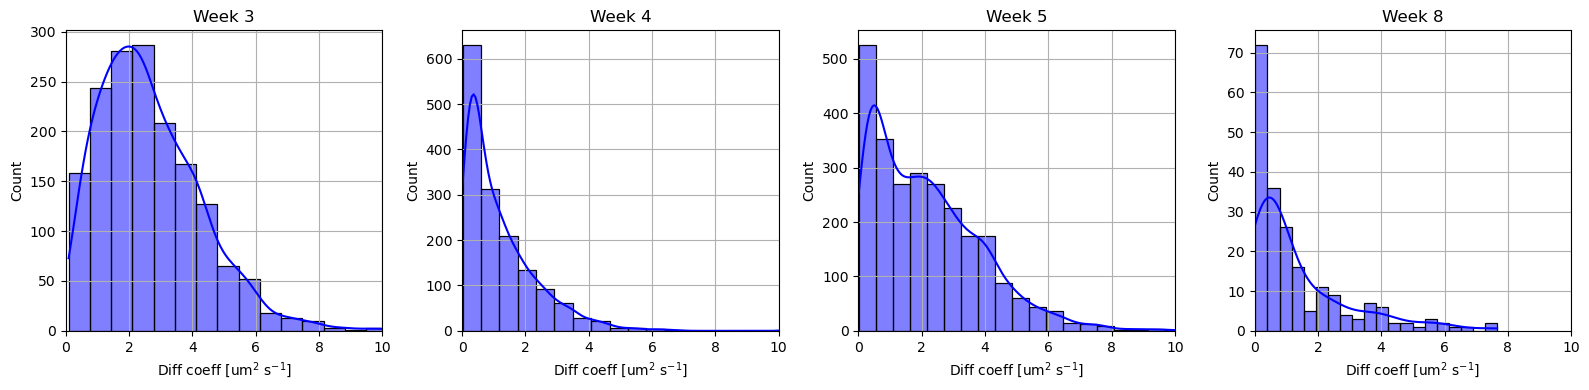

In [18]:
# Plot histogram for 'Inst diff coeff'

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
sns.histplot(data=D21_instdiff['D'].dropna(), bins=20, color='blue', kde=True)
plt.xlabel('Diff coeff [$\mathregular{um^{2}}$ $\mathregular{s^{-1}}$]')
plt.xlim(0,10)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
#plt.ylabel('Frequency')
plt.title('Week 3')
plt.grid(True)

plt.subplot(1, 4, 2)
sns.histplot(data=D28_instdiff['D'].dropna(), bins=20, color='blue', kde=True)
plt.xlabel('Diff coeff [$\mathregular{um^{2}}$ $\mathregular{s^{-1}}$]')
plt.xlim(0,10)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
#plt.ylabel('Frequency')
plt.title('Week 4')
plt.grid(True)

plt.subplot(1, 4, 3)
sns.histplot(data=D35_instdiff['D'].dropna(), bins=20, color='blue', kde=True)
plt.xlabel('Diff coeff [$\mathregular{um^{2}}$ $\mathregular{s^{-1}}$]')
plt.xlim(0,10)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
#plt.ylabel('Frequency')
plt.title('Week 5')
plt.grid(True)

plt.subplot(1, 4, 4)
sns.histplot(data=D55_instdiff['D'].dropna(), bins=20, color='blue', kde=True)
plt.xlabel('Diff coeff [$\mathregular{um^{2}}$ $\mathregular{s^{-1}}$]')
plt.xlim(0,10)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
#plt.ylabel('Frequency')
plt.title('Week 8')
plt.grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

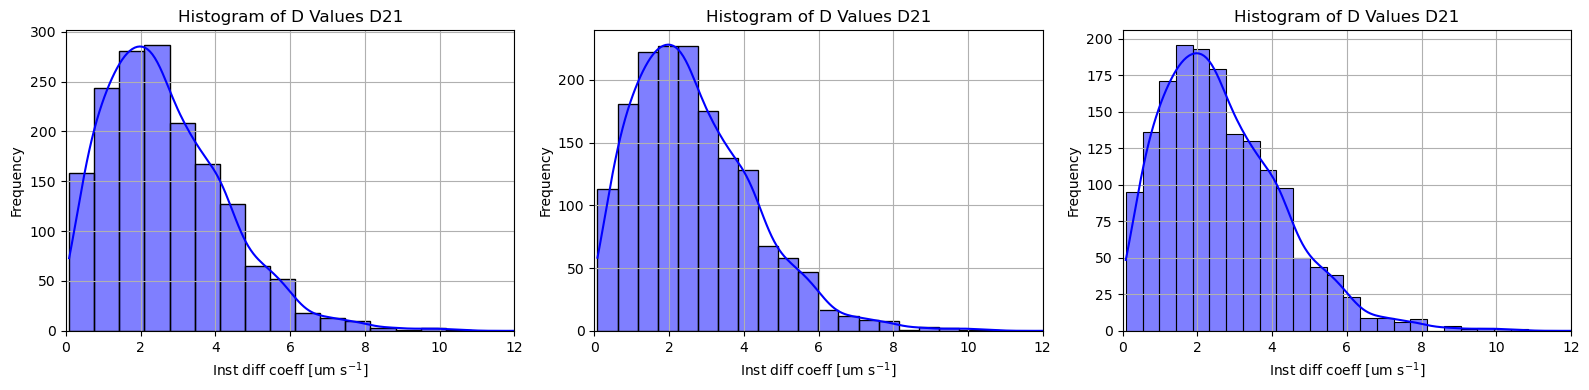

In [45]:
# Plot histogram for 'Inst diff coeff'

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
sns.histplot(data=instdiff['D'].dropna(), bins=20, color='blue', kde=True)
plt.xlabel('Inst diff coeff [um $\mathregular{s^{-1}}$]')
plt.xlim(0,12)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.ylabel('Frequency')
plt.title('Histogram of D Values D21')
plt.grid(True)

plt.subplot(1, 3, 2)
sns.histplot(data=instdiff['D'].dropna(), bins=25, color='blue', kde=True)
plt.xlabel('Inst diff coeff [um $\mathregular{s^{-1}}$]')
plt.xlim(0,12)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.ylabel('Frequency')
plt.title('Histogram of D Values D21')
plt.grid(True)

plt.subplot(1, 3, 3)
sns.histplot(data=instdiff['D'].dropna(), bins=30, color='blue', kde=True)
plt.xlabel('Inst diff coeff [um $\mathregular{s^{-1}}$]')
plt.xlim(0,12)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.ylabel('Frequency')
plt.title('Histogram of D Values D21')
plt.grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [21]:
All_files = pd.concat(D21_all_files)
All_files.head()

,frame,roi_id,x,y,mean_spot_intensity,particle,file_roi_particle,unique_id,line,day,batch,file_name
0,0,1,335.879872,612.498656,861.861111,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
1,4,1,337.696727,614.071985,933.833333,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
2,5,1,338.554559,614.194560,985.527778,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
3,6,1,338.565542,614.210605,1072.361111,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
4,7,1,339.008871,615.038788,1022.305556,1,9_1_1,72,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...


Sum of the squared differences of x and y equals r sqared.